# Titanic Survival Prediction with Logistic Regression (scikit-learn)

---

## 1. Goal

---

The goal of this notebook is to build a binary classification model using scikit-learn's Logistic Regression implementation to predict passenger survival on the Titanic dataset.

The workflow includes:
- loading and exploring the dataset
- preparing features and target labels
- splitting the data into training and test sets
- training a logistic regression model
- evaluating model performance using common classification metrics

This notebook establishes a baseline implementation before building logistic regression from scratch in the next step of the project.

## 2. Imports

---

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## 3. Load Dataset

---

In [2]:
df = pd.read_csv("../../data/raw/titanic.csv")

In [3]:
df.head()

,sex,age,family_size,fare,1st_class,2nd_class,3rd_class,survived
0,1,22.0,1,7.2500,0,0,1,0
1,0,38.0,1,71.2833,1,0,0,1
2,0,26.0,0,7.9250,0,0,1,1
3,0,35.0,1,53.1000,1,0,0,1
4,1,35.0,0,8.0500,0,0,1,0


## 4. Prepare feature and targets

---
Split the dataset into input features (`X`) and target labels (`y`).

In [4]:
y = df["survived"]
X = df.drop(columns=["survived"])

## 5. Train Test Split

---
Split in Training and Testing set

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## 6. Feature Scaling

---

Continuous numerical features are standardized using `StandardScaler` to improve optimization stability and model performance.


In [6]:
continuous_features = ["age", "fare", "family_size"]

scaler = StandardScaler()
X_train[continuous_features] = scaler.fit_transform(X_train[continuous_features])
X_test[continuous_features] = scaler.transform(X_test[continuous_features])

In [7]:
X_train.describe()

,sex,age,family_size,fare,1st_class,2nd_class,3rd_class
count,709.000000,7.090000e+02,7.090000e+02,7.090000e+02,709.000000,709.000000,709.000000
mean,0.643159,2.330059e-16,-3.758160e-17,3.006528e-17,0.242595,0.212976,0.544429
std,0.479405,1.000706e+00,1.000706e+00,1.000706e+00,0.428955,0.409700,0.498374
min,0.000000,-2.044730e+00,-5.653090e-01,-6.833413e-01,0.000000,0.000000,0.000000
25%,0.000000,-6.408210e-01,-5.653090e-01,-5.144948e-01,0.000000,0.000000,0.000000
50%,1.000000,-1.164527e-01,-5.653090e-01,-3.744108e-01,0.000000,0.000000,1.000000
75%,1.000000,6.526209e-01,3.559667e-02,-1.461325e-02,0.000000,0.000000,1.000000
max,1.000000,3.519168e+00,5.443748e+00,1.023212e+01,1.000000,1.000000,1.000000


## 7. Train Logistic Regression Model

---


In [8]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

## 8. Make Predictions

---

In [9]:
y_pred = model.predict(X_test)

## 9. Model Evaluation

---

In [10]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

In [11]:
print(f"Accuracy: {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1 Score: {f1:.3f}")

print(classification_report(y_test, y_pred))

Accuracy: 0.787
Precision: 0.754
Recall: 0.667
F1 Score: 0.708
              precision    recall  f1-score   support

           0       0.80      0.86      0.83       109
           1       0.75      0.67      0.71        69

    accuracy                           0.79       178
   macro avg       0.78      0.76      0.77       178
weighted avg       0.78      0.79      0.78       178



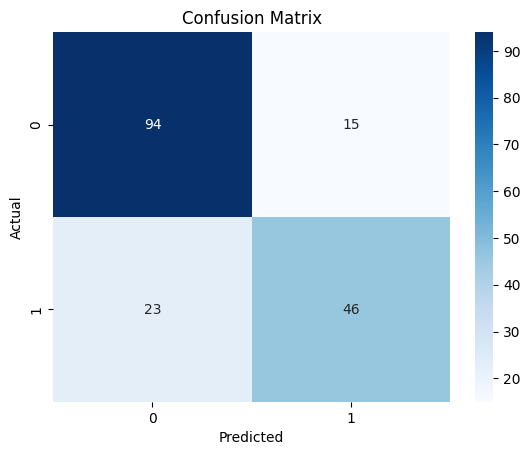

In [12]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## 10. Conclusion

---

The logistic regression baseline achieved an accuracy of approximately 79% and an F1 score of approximately 71%. This provides a solid reference point for the NumPy-based implementation.